In [1]:
import os
print("Current working directory:", os.getcwd())
print("Files in current directory:", os.listdir('.'))
os.chdir('C:/Users/Tom/Desktop/east_africa_conflict_analysis/')

Current working directory: c:\Users\Tom\Desktop\east_africa_conflict_analysis\notebooks
Files in current directory: ['exploratory_data_analysis.ipynb']


In [3]:
from src.data_cleaning import clean_data_pipeline
#from src.feature_engineering import prepare_features 

data = clean_data_pipeline()
#data = prepare_features(data)



Starting data cleaning pipeline...
<class 'xarray.core.dataarray.DataArray'>


c:\Users\Tom\anaconda3\envs\gisc412\Lib\site-packages\pyogrio\geopandas.py:265: UserWarning: More than one layer found in 'gadm41_KEN_shp': 'gadm41_KEN_0' (default), 'gadm41_KEN_1', 'gadm41_KEN_2', 'gadm41_KEN_3'. Specify layer parameter to avoid this warning.
  result = read_func(


Using existing C:\Users\Tom\Desktop\east_africa_conflict_analysis\data\kenya_police.parquet
Reprojection required: ken - police (Current: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)"}, {"name": "World Geodetic System 1984 (G730)"}, {"name": "World Geodetic System 1984 (G873)"}, {"name": "World Geodetic System 1984 (G1150)"}, {"name": "World Geodetic System 1984 (G1674)"}, {"name": "World Geodetic System 1984 (G1762)"}, {"name": "World Geodetic System 1984 (G2139)"}], "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}, "accuracy": "2.0", "id": {"authority": "EPSG", "code": 6326}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitu

In [3]:
data

{'eth': {},
 'ken': {'acled':                     WEEK          REGION COUNTRY      ADMIN1  \
  82503    24-January-1998  Eastern Africa   Kenya     Baringo   
  82504    16-January-1999  Eastern Africa   Kenya     Baringo   
  82505  25-September-1999  Eastern Africa   Kenya     Baringo   
  82506     07-August-2004  Eastern Africa   Kenya     Baringo   
  82507      02-April-2005  Eastern Africa   Kenya     Baringo   
  ...                  ...             ...     ...         ...   
  96899   07-December-2024  Eastern Africa   Kenya  West Pokot   
  96900     23-August-2025  Eastern Africa   Kenya  West Pokot   
  96901      09-April-2022  Eastern Africa   Kenya  West Pokot   
  96902        13-May-2023  Eastern Africa   Kenya  West Pokot   
  96903      16-March-2024  Eastern Africa   Kenya  West Pokot   
  
                         EVENT_TYPE   SUB_EVENT_TYPE  EVENTS  FATALITIES  \
  82503                     Battles      Armed clash       1           0   
  82504                  

In [12]:
import pandas as pd
import geopandas as gpd

COMMON_CRS = "EPSG:32637"

    # ACLED conflict data
acled_df = pd.read_csv("../data/Africa_aggregated_data_up_to-2025-08-23.csv")
acled_gdf = gpd.GeoDataFrame(
        acled_df,
        geometry=gpd.points_from_xy(
            acled_df['CENTROID_LONGITUDE'], 
            acled_df['CENTROID_LATITUDE']
        ),
        crs=COMMON_CRS
        )
    

acled_gdf[acled_gdf['COUNTRY'] == 'Kenya'].head()

,WEEK,REGION,COUNTRY,ADMIN1,EVENT_TYPE,SUB_EVENT_TYPE,EVENTS,FATALITIES,POPULATION_EXPOSURE,DISORDER_TYPE,ID,CENTROID_LATITUDE,CENTROID_LONGITUDE,geometry
82503,24-January-1998,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535.0,0.7197,36.0185,POINT (36.018 0.72)
82504,16-January-1999,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535.0,0.7197,36.0185,POINT (36.018 0.72)
82505,25-September-1999,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535.0,0.7197,36.0185,POINT (36.018 0.72)
82506,07-August-2004,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,1,NaN,Political violence,1535.0,0.7197,36.0185,POINT (36.018 0.72)
82507,02-April-2005,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535.0,0.7197,36.0185,POINT (36.018 0.72)


In [3]:
acled = gpd.read_file(
            "../data/Africa_aggregated_data_up_to-2025-08-23.csv",
            x='CENTROID_LONGITUDE',
            y='CENTROID_LATITUDE',
            crs='EPSG:4326'
        )

c:\Users\Tom\anaconda3\envs\gisc412\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: driver CSV does not support open option X
  return ogr_read(
c:\Users\Tom\anaconda3\envs\gisc412\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: driver CSV does not support open option Y
  return ogr_read(
c:\Users\Tom\anaconda3\envs\gisc412\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: driver CSV does not support open option CRS
  return ogr_read(


In [8]:
acled.head()
type(acled)

pandas.core.frame.DataFrame

In [13]:
import os
print("Current directory:", os.getcwd())
print("Parent directory contents:", os.listdir('..'))
if os.path.exists('../data/'):
    print("Data directory contents:", os.listdir('../data/'))

Current directory: c:\Users\Tom\Desktop\east_africa_conflict_analysis\notebooks
Parent directory contents: ['.git', '.gitignore', 'data', 'docs', 'main.py', 'notebooks', 'README.md', 'requirements.txt', 'src']
Data directory contents: ['Africa_aggregated_data_up_to-2025-08-23.csv', 'eth_pop_2020_CN_100m_R2025A_v1.tif', 'gadm41_ETH_shp', 'gadm41_KEN_shp', 'gadm41_SSD_shp', 'gadm41_UGA_shp', 'ken_pop_2020_CN_100m_R2025A_v1.tif', 'ssd_pop_2020_CN_100m_R2025A_v1.tif', 'uga_pop_2020_CN_100m_R2025A_v1.tif', '_archive']


In [14]:
acled_df = pd.read_csv("../data/Africa_aggregated_data_up_to-2025-08-23.csv")

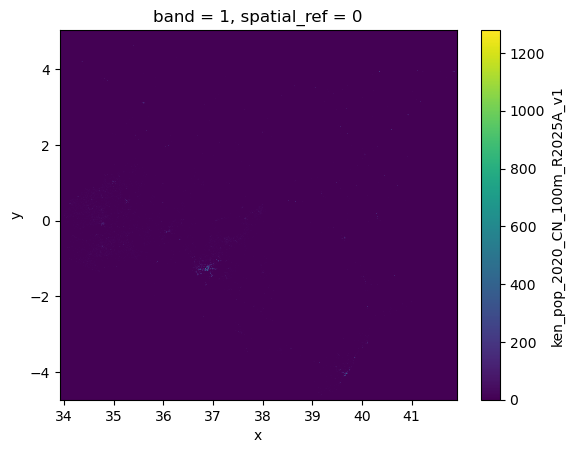

In [4]:
data['ken']['population'].plot()

In [5]:
dataset = data['ken']['population']
print(f"Min: {dataset.min().values}")
dataset_cleaned = dataset.where(dataset != -99999.0, 0)
print(f"Min: {dataset_cleaned.min().values}")

Min: -99999.0
Min: 0.0


In [27]:
import rioxarray as rxr
data['ken']['population'] = rxr.open_rasterio("data/ken_pop_2020_CN_100m_R2025A_v1.tif")
print(type(data['ken']['population'])) 

<class 'xarray.core.dataarray.DataArray'>


In [4]:
data['ken']['population'].rio.crs

CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]')

In [6]:
data['ken']['acled'].crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [8]:
data['ken']['police'].crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [10]:
data['ken']['bounds'].crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [4]:
data['ken']['bounds'].head()


,GID_0,COUNTRY,geometry
0,KEN,Kenya,"MULTIPOLYGON (((39.38014 -4.71792, 39.37986 -4..."


In [4]:
# ACLED: Check for impossible coordinates, extreme casualty numbers
ken_acled = data['ken']['acled']

# Check impossible coordinates (latitude should be between -90 and 90, longitude between -180 and 180)
print("Invalid coordinates:")
print(ken_acled[(ken_acled.geometry.y < -90) | (ken_acled.geometry.y > 90) | 
               (ken_acled.geometry.x < -180) | (ken_acled.geometry.x > 180)])

# Check extreme casualty numbers
print("\nCasualty statistics:")
print(ken_acled['FATALITIES'].describe())
print("\nHigh fatality events (>100):")
print(ken_acled[ken_acled['FATALITIES'] > 100][['WEEK', 'FATALITIES', 'EVENT_TYPE']])

# Boundaries: Check for invalid geometries
ken_bounds = data['ken']['bounds']

print("\nInvalid geometries:")
print(f"Number of invalid geometries: {(~ken_bounds.geometry.is_valid).sum()}")
print(ken_bounds[~ken_bounds.geometry.is_valid])

# Population: Clip extreme values
ken_pop = data['ken']['population']

print("\nPopulation statistics:")
print(f"Min: {ken_pop.min().values}")
print(f"Max: {ken_pop.max().values}")
print(f"Mean: {ken_pop.mean().values}")
print(f"Median: {ken_pop.median().values}")

# Check for extreme values (e.g., above 99th percentile)
percentile_99 = ken_pop.quantile(0.99).values
print(f"\n99th percentile: {percentile_99}")
print(f"Values above 99th percentile: {(ken_pop > percentile_99).sum().values}")

Invalid coordinates:
Empty GeoDataFrame
Columns: [WEEK, REGION, COUNTRY, ADMIN1, EVENT_TYPE, SUB_EVENT_TYPE, EVENTS, FATALITIES, POPULATION_EXPOSURE, DISORDER_TYPE, ID, CENTROID_LATITUDE, CENTROID_LONGITUDE, geometry]
Index: []

Casualty statistics:
count    14401.000000
mean         1.034442
std          5.135206
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max        281.000000
Name: FATALITIES, dtype: float64

High fatality events (>100):
                  WEEK  FATALITIES                  EVENT_TYPE
84342    28-March-2015         149  Violence against civilians
88909   14-August-1999         153                     Battles
91233   01-August-1998         213  Explosions/Remote violence
96619  24-October-1998         281  Violence against civilians

Invalid geometries:
Number of invalid geometries: 0
Empty GeoDataFrame
Columns: [GID_0, COUNTRY, geometry]
Index: []

Population statistics:
Min: -99999.0
Max: 1279.02294921875
Mean: -88890.88281

# ---                   ---

In [1]:
import os
print("Current working directory:", os.getcwd())
print("Files in current directory:", os.listdir('.'))
os.chdir('C:/Users/Tom/Desktop/east_africa_conflict_analysis/')

Current working directory: c:\Users\Tom\Desktop\east_africa_conflict_analysis\notebooks
Files in current directory: ['exploratory_data_analysis.ipynb']


In [2]:
from src.data_cleaning import clean_data_pipeline
from src.feature_engineering import feature_engineering_pipeline



In [3]:
data = clean_data_pipeline()

Starting data cleaning pipeline...
<class 'xarray.core.dataarray.DataArray'>
Using existing C:\Users\Tom\Desktop\east_africa_conflict_analysis\data\kenya_police.parquet
Replaced 100583464 missing values (-99999.0) with 0 in ken - population
Data cleaning complete.


In [4]:
data = feature_engineering_pipeline(data)


Starting feature engineering pipeline for: ken
  - Spatially joining ACLED events to admin units...
  - Spatially joining police stations to admin units...
  -> Aggregation complete: conflict_count & police_count added.
Adding population from raster to admin units...
  - Population raster CRS: EPSG:32637
  - Running zonal statistics (sum of population per unit). This may take a moment...
  -> Population added to features (NaN for zero-pop units).
Creating rates and densities...
  -> Rates & log-transforms created.
Feature engineering pipeline complete.


In [5]:
print(data['ken']['acled'].geometry.head())
print(data['ken']['bounds'].geometry.head())
print(data['ken']['police'].geometry.head())

82503    POINT (168108.914 79657.057)
82504    POINT (168108.914 79657.057)
82505    POINT (168108.914 79657.057)
82506    POINT (168108.914 79657.057)
82507    POINT (168108.914 79657.057)
Name: geometry, dtype: geometry
0    POLYGON ((152345.033 -3290.942, 152313.574 -32...
1    POLYGON ((143483.385 37584.199, 143477.845 375...
2    POLYGON ((145253.397 66726.962, 145221.464 666...
3    POLYGON ((191582.187 46801.179, 191573.654 467...
4    POLYGON ((146342.228 2700.663, 146374.963 2688...
Name: geometry, dtype: geometry
element  id       
node     30088453     POINT (244741.054 -146213.776)
         30118813     POINT (256115.833 -143480.551)
         30498715     POINT (259168.731 -142520.637)
         30694169     POINT (254647.411 -142888.864)
         291685265    POINT (259964.192 -139354.915)
Name: geometry, dtype: geometry


In [6]:
features = data['ken']['features']
features.head(100)
#features.columns


,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,...,HASC_2,geometry,conflict_count,police_count,population,area_km2,conflict_rate_per_100k,police_per_10k,log_conflict_rate,log_police_density
0,KEN.1.1_1,KEN,Kenya,KEN.1_1,Baringo,NA,805,NA,NA,Constituency,...,NA,"POLYGON ((152345.033 -3290.942, 152313.574 -32...",0,0,29270.878906,174.204213,0.000000,0.000000,-13.815511,-13.815511
1,KEN.1.2_1,KEN,Kenya,KEN.1_1,Baringo,NA,Baringo Central,NA,NA,Constituency,...,NA,"POLYGON ((143483.385 37584.199, 143477.845 375...",0,2,88579.703125,662.819663,0.000000,0.225785,-13.815511,-1.488166
2,KEN.1.3_1,KEN,Kenya,KEN.1_1,Baringo,NA,Baringo North,NA,NA,Constituency,...,NA,"POLYGON ((145253.397 66726.962, 145221.464 666...",371,1,99490.070312,1636.756218,372.901536,0.100513,5.921314,-2.297463
3,KEN.1.4_1,KEN,Kenya,KEN.1_1,Baringo,NA,Baringo South,NA,NA,Constituency,...,NA,"POLYGON ((191582.187 46801.179, 191573.654 467...",0,3,107116.171875,1888.569792,0.000000,0.280070,-13.815511,-1.272713
4,KEN.1.5_1,KEN,Kenya,KEN.1_1,Baringo,NA,Eldama Ravine,NA,NA,Constituency,...,NA,"POLYGON ((146342.228 2700.663, 146374.963 2688...",0,1,122005.023438,907.928242,0.000000,0.081964,-13.815511,-2.501465
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,KEN.14.7_1,KEN,Kenya,KEN.14_1,Kilifi,NA,Rabai,NA,NA,Constituency,...,NA,"POLYGON ((558070.748 -432551.899, 558206.399 -...",0,0,139264.906250,200.390060,0.000000,0.000000,-13.815511,-13.815511
96,KEN.15.1_1,KEN,Kenya,KEN.15_1,Kirinyaga,NA,Gichugu,NA,NA,Constituency,...,NA,"MULTIPOLYGON (((324675.193 -53018.087, 324669....",212,0,262481.343750,542.028805,80.767645,0.000000,4.391576,-13.815511
97,KEN.15.2_1,KEN,Kenya,KEN.15_1,Kirinyaga,NA,Kirinyaga Central,NA,NA,Constituency,...,NA,"POLYGON ((312214.408 -58852.61, 312232.245 -58...",0,0,238900.687500,237.341534,0.000000,0.000000,-13.815511,-13.815511
98,KEN.15.3_1,KEN,Kenya,KEN.15_1,Kirinyaga,NA,Mwea,NA,NA,Constituency,...,NA,"POLYGON ((307202.021 -86406.81, 307225.392 -86...",0,0,267115.906250,548.054538,0.000000,0.000000,-13.815511,-13.815511


In [7]:
features[['conflict_count', 'police_count', 'population']].describe()

#features.plot(column='conflict_count', legend=True)


,conflict_count,police_count,population
count,300.000000,300.000000,300.000000
mean,48.003333,1.626667,172713.089794
std,148.193435,2.637640,95509.489170
min,0.000000,0.000000,2463.139404
25%,0.000000,0.000000,115774.861328
50%,0.000000,1.000000,157360.867188
75%,0.000000,2.000000,207601.167969
max,1749.000000,16.000000,909340.062500


In [10]:
features.crs


<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

<Axes: >

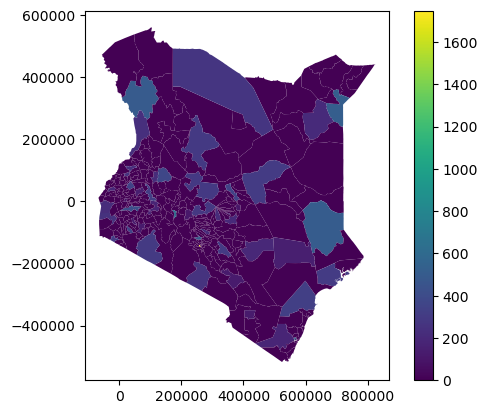

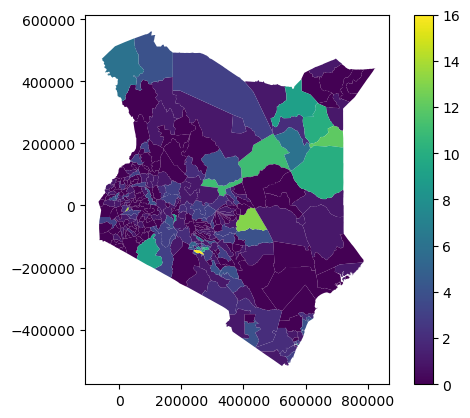

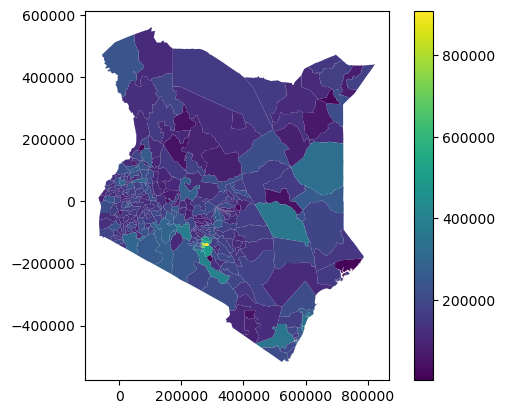

In [8]:
data['ken']['features'].plot(column='conflict_count', legend=True)
data['ken']['features'].plot(column='police_count', legend=True)
data['ken']['features'].plot(column='population', legend=True)


## ESDA

<Axes: >

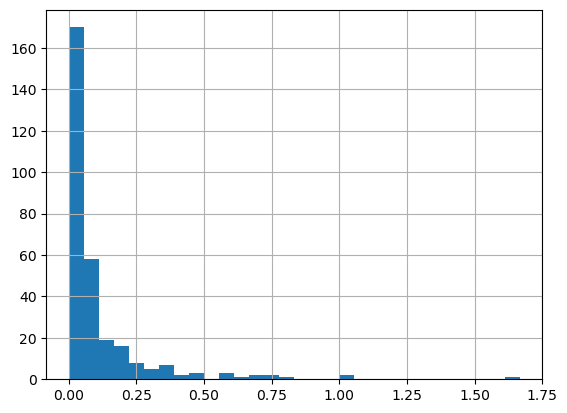

In [15]:
gdf = data['ken']['features']
gdf.columns

# Basic summary
gdf[['conflict_count', 'police_count', 'population', 'conflict_rate_per_100k', 'police_per_10k']].describe()

# Histograms
#gdf['conflict_count'].hist(bins=30)
#gdf['conflict_rate_per_100k'].hist(bins=30)
gdf['police_per_10k'].hist(bins=30)


<Axes: >

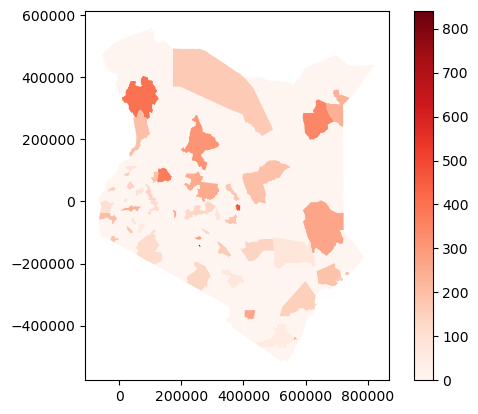

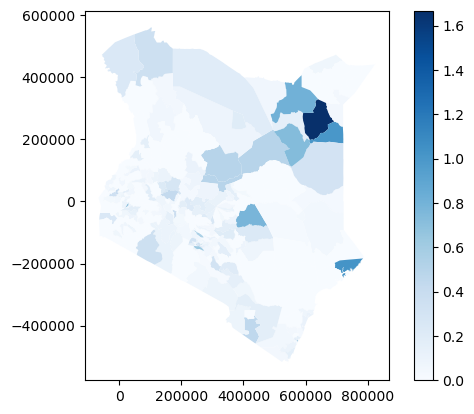

In [16]:
gdf.plot(column='conflict_rate_per_100k', legend=True, cmap='Reds')
gdf.plot(column='police_per_10k', legend=True, cmap='Blues')


<Axes: >

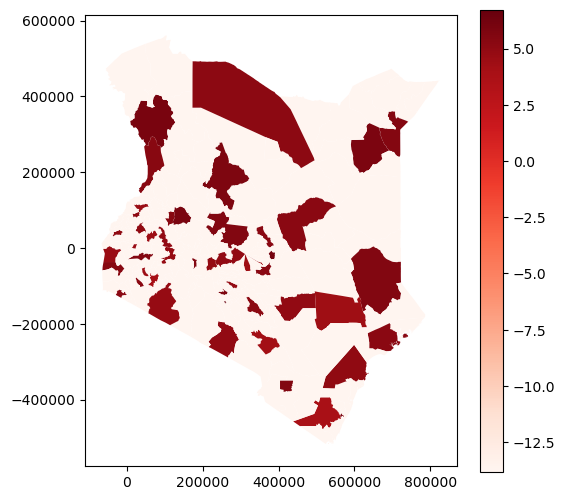

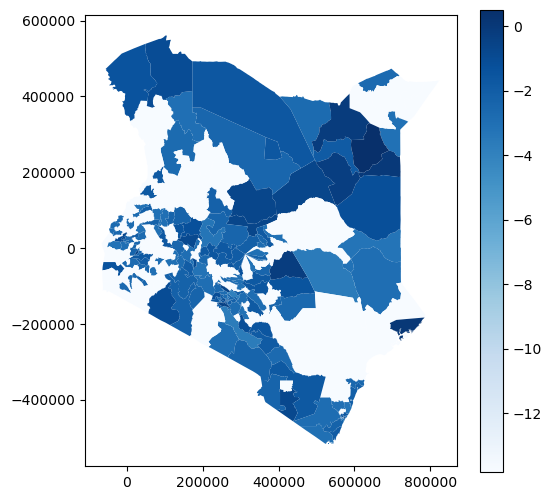

In [17]:
# Optional: log versions (might show clearer patterns)
gdf.plot(column='log_conflict_rate', legend=True, cmap='Reds', figsize=(6,6))
gdf.plot(column='log_police_density', legend=True, cmap='Blues', figsize=(6,6))

In [18]:
from libpysal.weights import Queen

w = Queen.from_dataframe(gdf)
w.transform = 'r'  # row-standardize



C:\Users\Tom\AppData\Local\Temp\ipykernel_37060\1921792489.py:3: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)


In [20]:
from esda import Moran

# For conflict
m_conflict = Moran(gdf['conflict_rate_per_100k'].values, w)
print(m_conflict.I, m_conflict.p_sim)

# For police
m_police = Moran(gdf['police_per_10k'].values, w)
print(m_police.I, m_police.p_sim)


-0.06734415092992159 0.008
0.22089100465146846 0.001


In [21]:
from libpysal.weights import Queen

w = Queen.from_dataframe(gdf)
w.transform = 'r'   # row-standardize


C:\Users\Tom\AppData\Local\Temp\ipykernel_37060\3091255753.py:3: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)


In [22]:
from esda import Moran_Local
import numpy as np
lisa_conflict = Moran_Local(gdf['conflict_rate_per_100k'], w)


In [23]:
lisa_police = Moran_Local(gdf['police_per_10k'], w)


In [24]:
def add_lisa_results(gdf, lisa, prefix):
    gdf[f'{prefix}_Is'] = lisa.Is
    gdf[f'{prefix}_p'] = lisa.p_sim

    # 1 = HH, 2 = LH, 3 = LL, 4 = HL, 0 = non-significant
    sig = lisa.p_sim < 0.05
    gdf[f'{prefix}_cluster'] = 0
    gdf.loc[sig & (lisa.q==1), f'{prefix}_cluster'] = 1  # High-High
    gdf.loc[sig & (lisa.q==2), f'{prefix}_cluster'] = 2  # Low-High
    gdf.loc[sig & (lisa.q==3), f'{prefix}_cluster'] = 3  # Low-Low
    gdf.loc[sig & (lisa.q==4), f'{prefix}_cluster'] = 4  # High-Low

    return gdf

gdf = add_lisa_results(gdf, lisa_conflict, 'conflict')
gdf = add_lisa_results(gdf, lisa_police, 'police')


In [28]:
cluster_labels = {
    0: 'Not significant',
    1: 'High-High',
    2: 'Low-High',
    3: 'Low-Low',
    4: 'High-Low'
}

# For conflict
gdf['conflict_cluster_label'] = gdf['conflict_cluster'].map(cluster_labels)

# For police
gdf['police_cluster_label'] = gdf['police_cluster'].map(cluster_labels)



<Axes: >

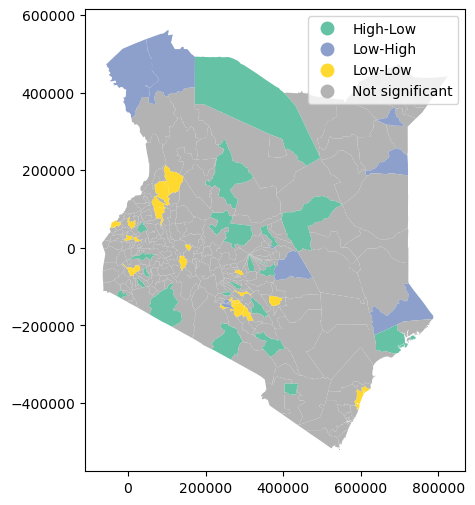

In [31]:
gdf.plot(column='conflict_cluster_label',
         categorical=True,
         legend=True,
         cmap='Set2',
         figsize=(6,6))



<Axes: >

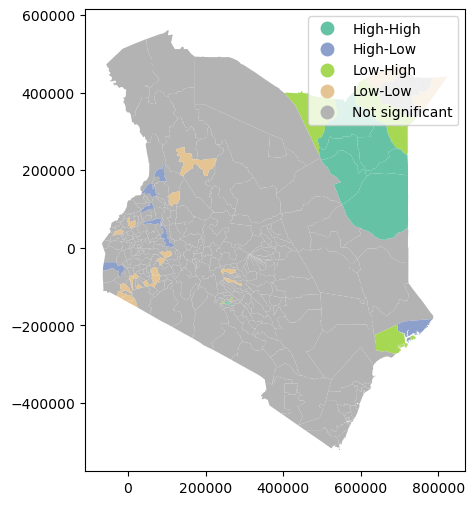

In [32]:
gdf.plot(column='police_cluster_label',
         categorical=True,
         legend=True,
         cmap='Set2',
         figsize=(6,6))

In [33]:
gdf[['conflict_rate_per_100k', 'police_per_10k']].corr()


,conflict_rate_per_100k,police_per_10k
conflict_rate_per_100k,1.000000,0.118114
police_per_10k,0.118114,1.000000


<Axes: xlabel='log_police_density', ylabel='log_conflict_rate'>

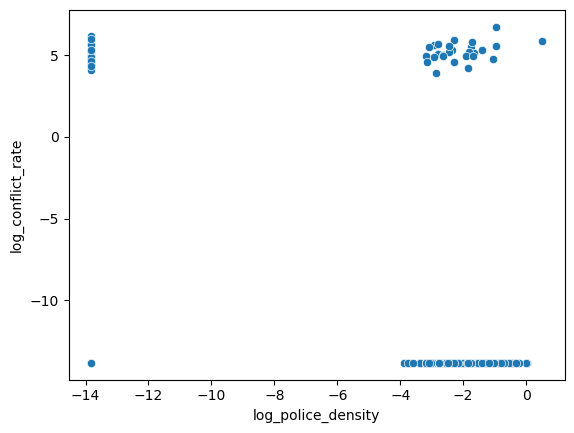

In [36]:
import seaborn as sns
#sns.scatterplot(x='police_per_10k', y='conflict_rate_per_100k', data=gdf)
sns.scatterplot(x='log_police_density', y='log_conflict_rate', data=gdf)
